In [1]:
# The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the Titanic dataset. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [5]:
# Uploading dataset

In [11]:
titanic_df= pd.read_csv('Titanic_train.csv')
titanic_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [13]:
titanic_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
titanic_df.shape

(891, 12)

In [19]:
# Missing values

In [25]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
# Data distributions

In [29]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [31]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [36]:
# Explore data distributions using box plots and histograms



In [38]:
# Remove duplicates

titanic_df[titanic_df.duplicated()] #No duplicates

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [50]:
titanic_df['Name'].value_counts()

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64

In [ ]:
# Since all are unique values, this does not add upto any meaningful data and so removed from the dataframe.

In [54]:
titanic_df=titanic_df.drop(columns=['Name'])

In [56]:
titanic_df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,male,26.0,0,0,111369,30.0000,C148,C


In [58]:
687/891

0.7710437710437711

In [ ]:
# 77% of data is missing in the column 'Cabin'. This column is hence ideal to be dropped, otherwise this can lead to bias.

In [60]:
titanic_df=titanic_df.drop(columns=['Cabin'])

In [66]:
titanic_df.shape

(891, 10)

In [68]:
titanic_df['Ticket'].nunique()

681

In [74]:
titanic_df['Ticket'].value_counts()

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64

In [ ]:
# Pie chart to analyze the column 'Ticket'

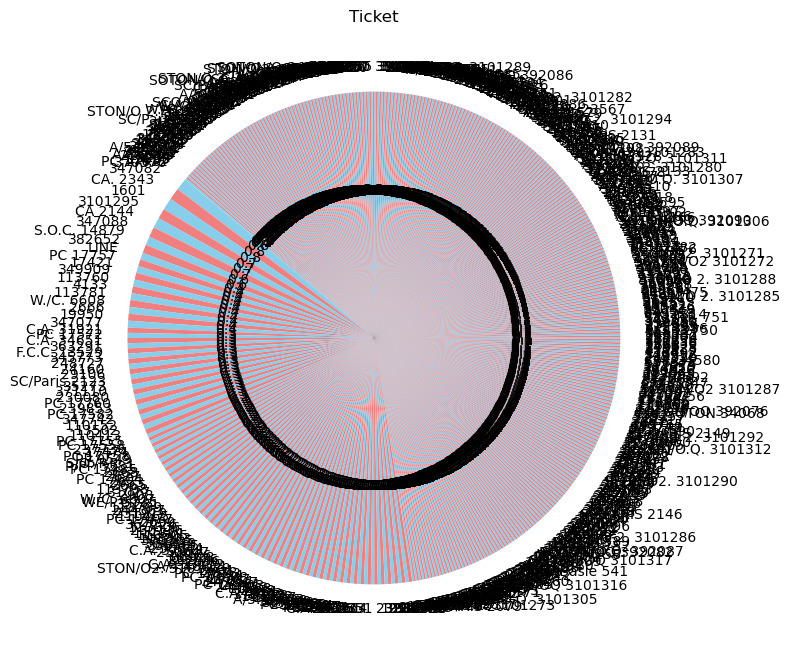

In [76]:
category_counts=titanic_df['Ticket'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts.values, labels= category_counts.index, autopct ="%1.1f", startangle=140, colors=['skyblue','lightcoral'])
plt.title('Ticket')
plt.show()

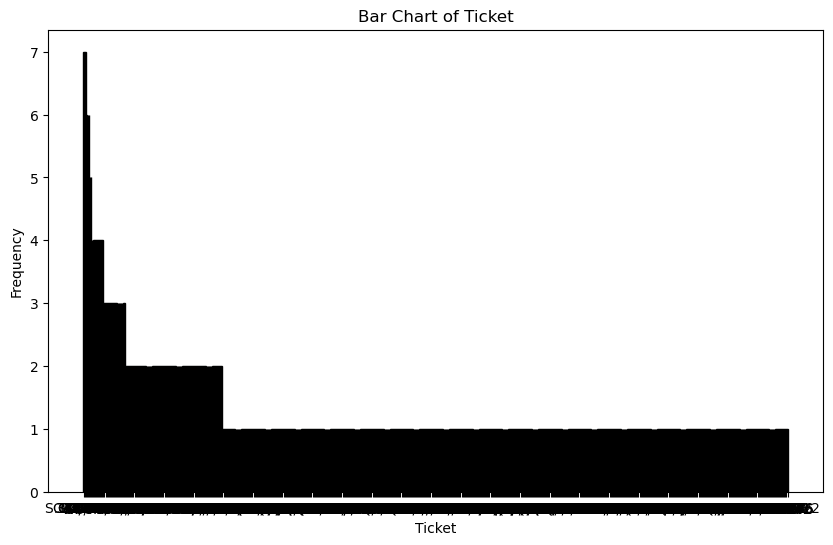

In [78]:
# Bar chart

# Example: Bar chart for the "Sex" column in the Titanic dataset
category_counts = titanic_df['Ticket'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')
plt.title('Bar Chart of Ticket')
plt.xlabel('Ticket')
plt.ylabel('Frequency')
plt.show()


C:\Users\Smrithi\AppData\Local\Temp\ipykernel_28696\2266990452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic_df, x='Ticket', palette='pastel')


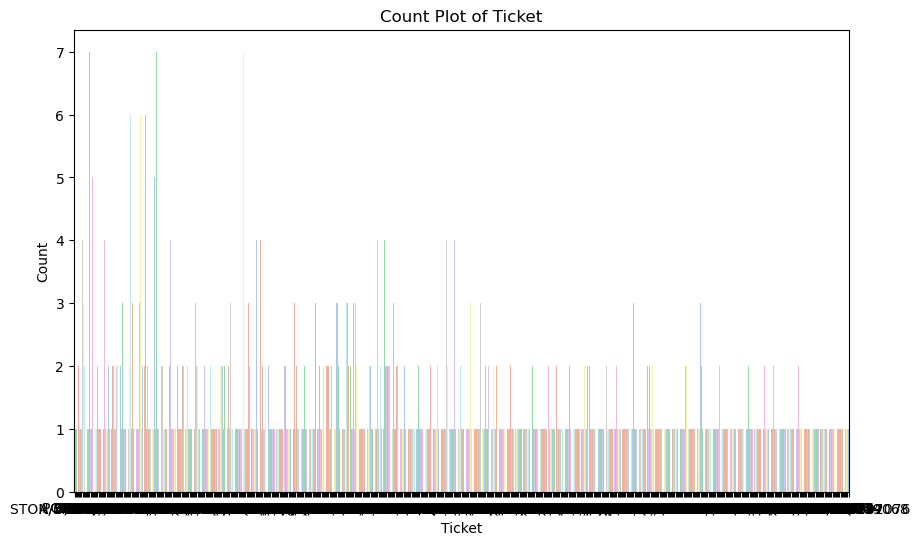

In [86]:
# Count plot

# Example: Count plot for the "Sex" column in the Titanic dataset
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic_df, x='Ticket', palette='pastel')
plt.title('Count Plot of Ticket')
plt.xlabel('Ticket')
plt.ylabel('Count')
plt.show()


In [88]:
# Checking significance of column 'Ticket'
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(titanic_df['Ticket'], titanic_df['Survived'])
chi2, p, _, _ = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"P-value: {p}")

# If p-value < 0.05, there is a significant association
if p < 0.05:
    print("There is a significant association between Ticket and Survived.")
else:
    print("There is no significant association between Ticket and Survived.")


Chi-square statistic: 766.5697029458893
P-value: 0.01152729601163775
There is a significant association between Ticket and Survived.


In [ ]:
# One hot encoding of categorical variables

In [90]:
# titanic_df=pd.get_dummies(titanic_df,columns=[''])
681/891

0.7643097643097643

In [ ]:
# Since column 'Ticket' seem to be ticket ids and does not seem to contribute to predictability, this can be removed. Also the data has high cardinality
# and can act as noise in the model if not removed. Hence dropping the column.

In [97]:
titanic_df=titanic_df.drop(columns=['Ticket'])

In [101]:
titanic_df.shape

(891, 9)

In [103]:
titanic_df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C


In [105]:
titanic_df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [107]:
titanic_df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [111]:
titanic_df['PassengerId'].value_counts()

PassengerId
1      1
599    1
588    1
589    1
590    1
      ..
301    1
302    1
303    1
304    1
891    1
Name: count, Length: 891, dtype: int64

In [ ]:
# Resetting passenger ID to index

In [208]:
titanic_df_n = titanic_df.set_index(['PassengerId'])
titanic_df_n

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S
888,1,1,female,19.0,0,0,30.0000,S
889,0,3,female,NaN,1,2,23.4500,S


In [ ]:
# One hot encoding of columns 'Embarked' and 'Sex'

In [210]:
# titanic_df_n = pd.get_dummies(titanic_df_n, columns=['Sex']).astype(int)

titanic_df_n = pd.get_dummies(titanic_df_n, columns=['Sex'])

In [212]:
titanic_df_n['Sex_male'].value_counts()

Sex_male
True     577
False    314
Name: count, dtype: int64

In [214]:
titanic_df_n['Sex_male'].isnull().sum()

0

In [216]:
titanic_df_n['Sex_female'].value_counts()

Sex_female
False    577
True     314
Name: count, dtype: int64

In [218]:
titanic_df_n['Sex_female'].isnull().sum()

0

In [220]:
titanic_df_n = pd.get_dummies(titanic_df_n, columns=['Embarked'])

In [222]:
titanic_df_n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         714 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_female  891 non-null    bool   
 7   Sex_male    891 non-null    bool   
 8   Embarked_C  891 non-null    bool   
 9   Embarked_Q  891 non-null    bool   
 10  Embarked_S  891 non-null    bool   
dtypes: bool(5), float64(2), int64(4)
memory usage: 53.1 KB


In [224]:
# Converting boolean into numericals

In [226]:
titanic_df_n[['Sex_male','Sex_female','Embarked_C','Embarked_Q','Embarked_S']]= titanic_df_n[['Sex_male','Sex_female','Embarked_C','Embarked_Q','Embarked_S']].astype(int)

In [228]:
titanic_df_n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         714 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_female  891 non-null    int32  
 7   Sex_male    891 non-null    int32  
 8   Embarked_C  891 non-null    int32  
 9   Embarked_Q  891 non-null    int32  
 10  Embarked_S  891 non-null    int32  
dtypes: float64(2), int32(5), int64(4)
memory usage: 66.1 KB


In [230]:
titanic_df_n.isnull().sum()

Survived        0
Pclass          0
Age           177
SibSp           0
Parch           0
Fare            0
Sex_female      0
Sex_male        0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

In [232]:
m = titanic_df_n['Age'].median()

In [234]:
m

28.0

In [236]:
titanic_df_n['Age']=titanic_df_n['Age'].fillna(m)

In [238]:
titanic_df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [240]:
titanic_df_n['Age'].value_counts()

Age
28.00    202
24.00     30
22.00     27
18.00     26
19.00     25
        ... 
36.50      1
55.50      1
0.92       1
23.50      1
74.00      1
Name: count, Length: 88, dtype: int64

In [242]:
# Missing values imputed with median values

In [244]:
# Checking for outliers

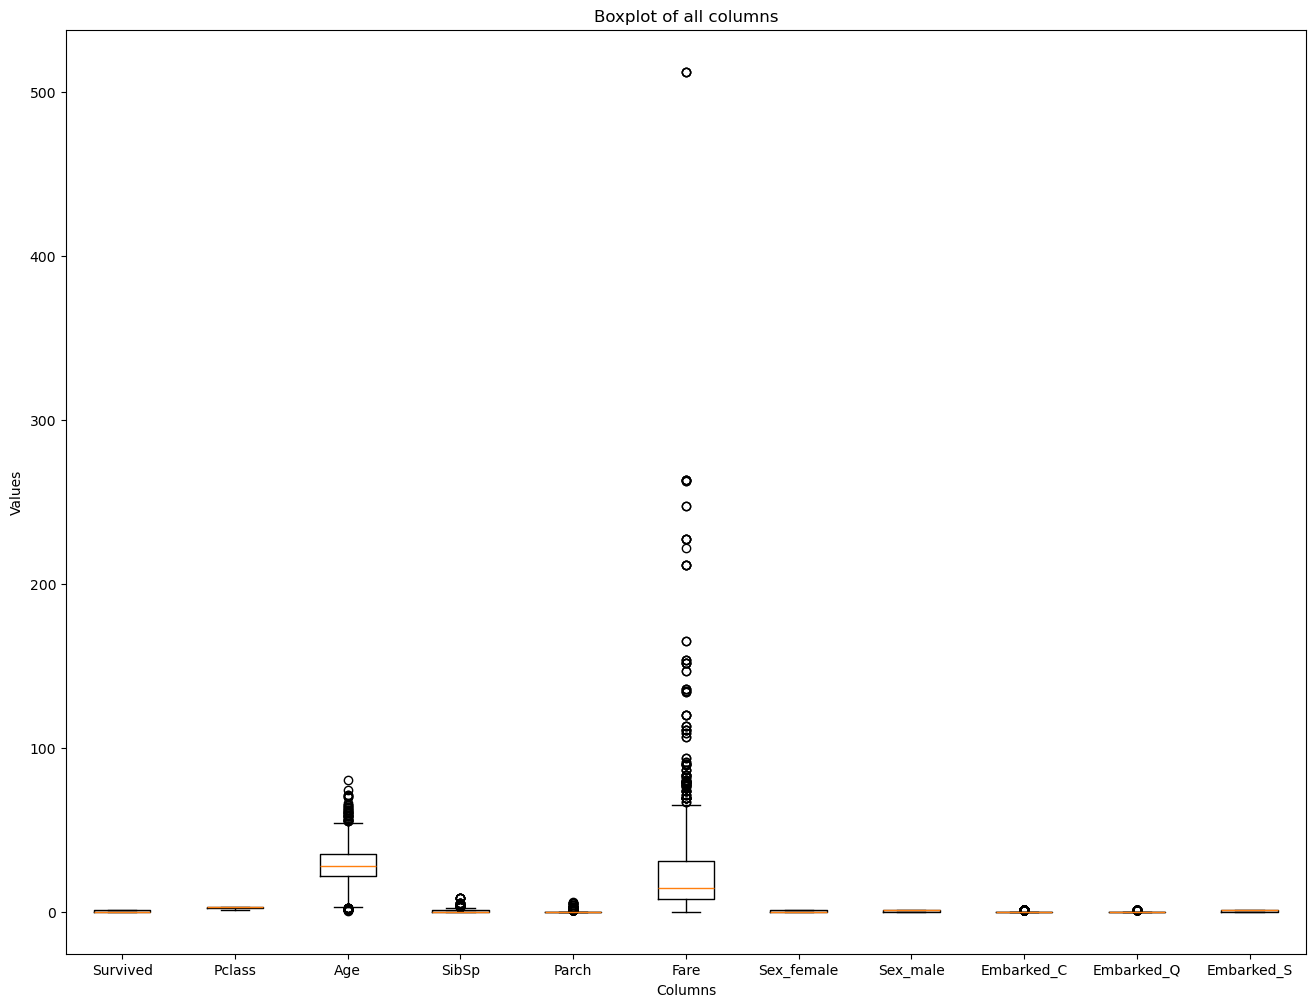

In [246]:
plt.figure(figsize=(16,12))
plt.boxplot([titanic_df_n[col] for col in titanic_df_n.columns], tick_labels = titanic_df_n.columns)
plt.title('Boxplot of all columns')
plt.xlabel('Columns')
plt.ylabel('Values')
plt.show()

In [248]:
# Histogram of all the columns

import math

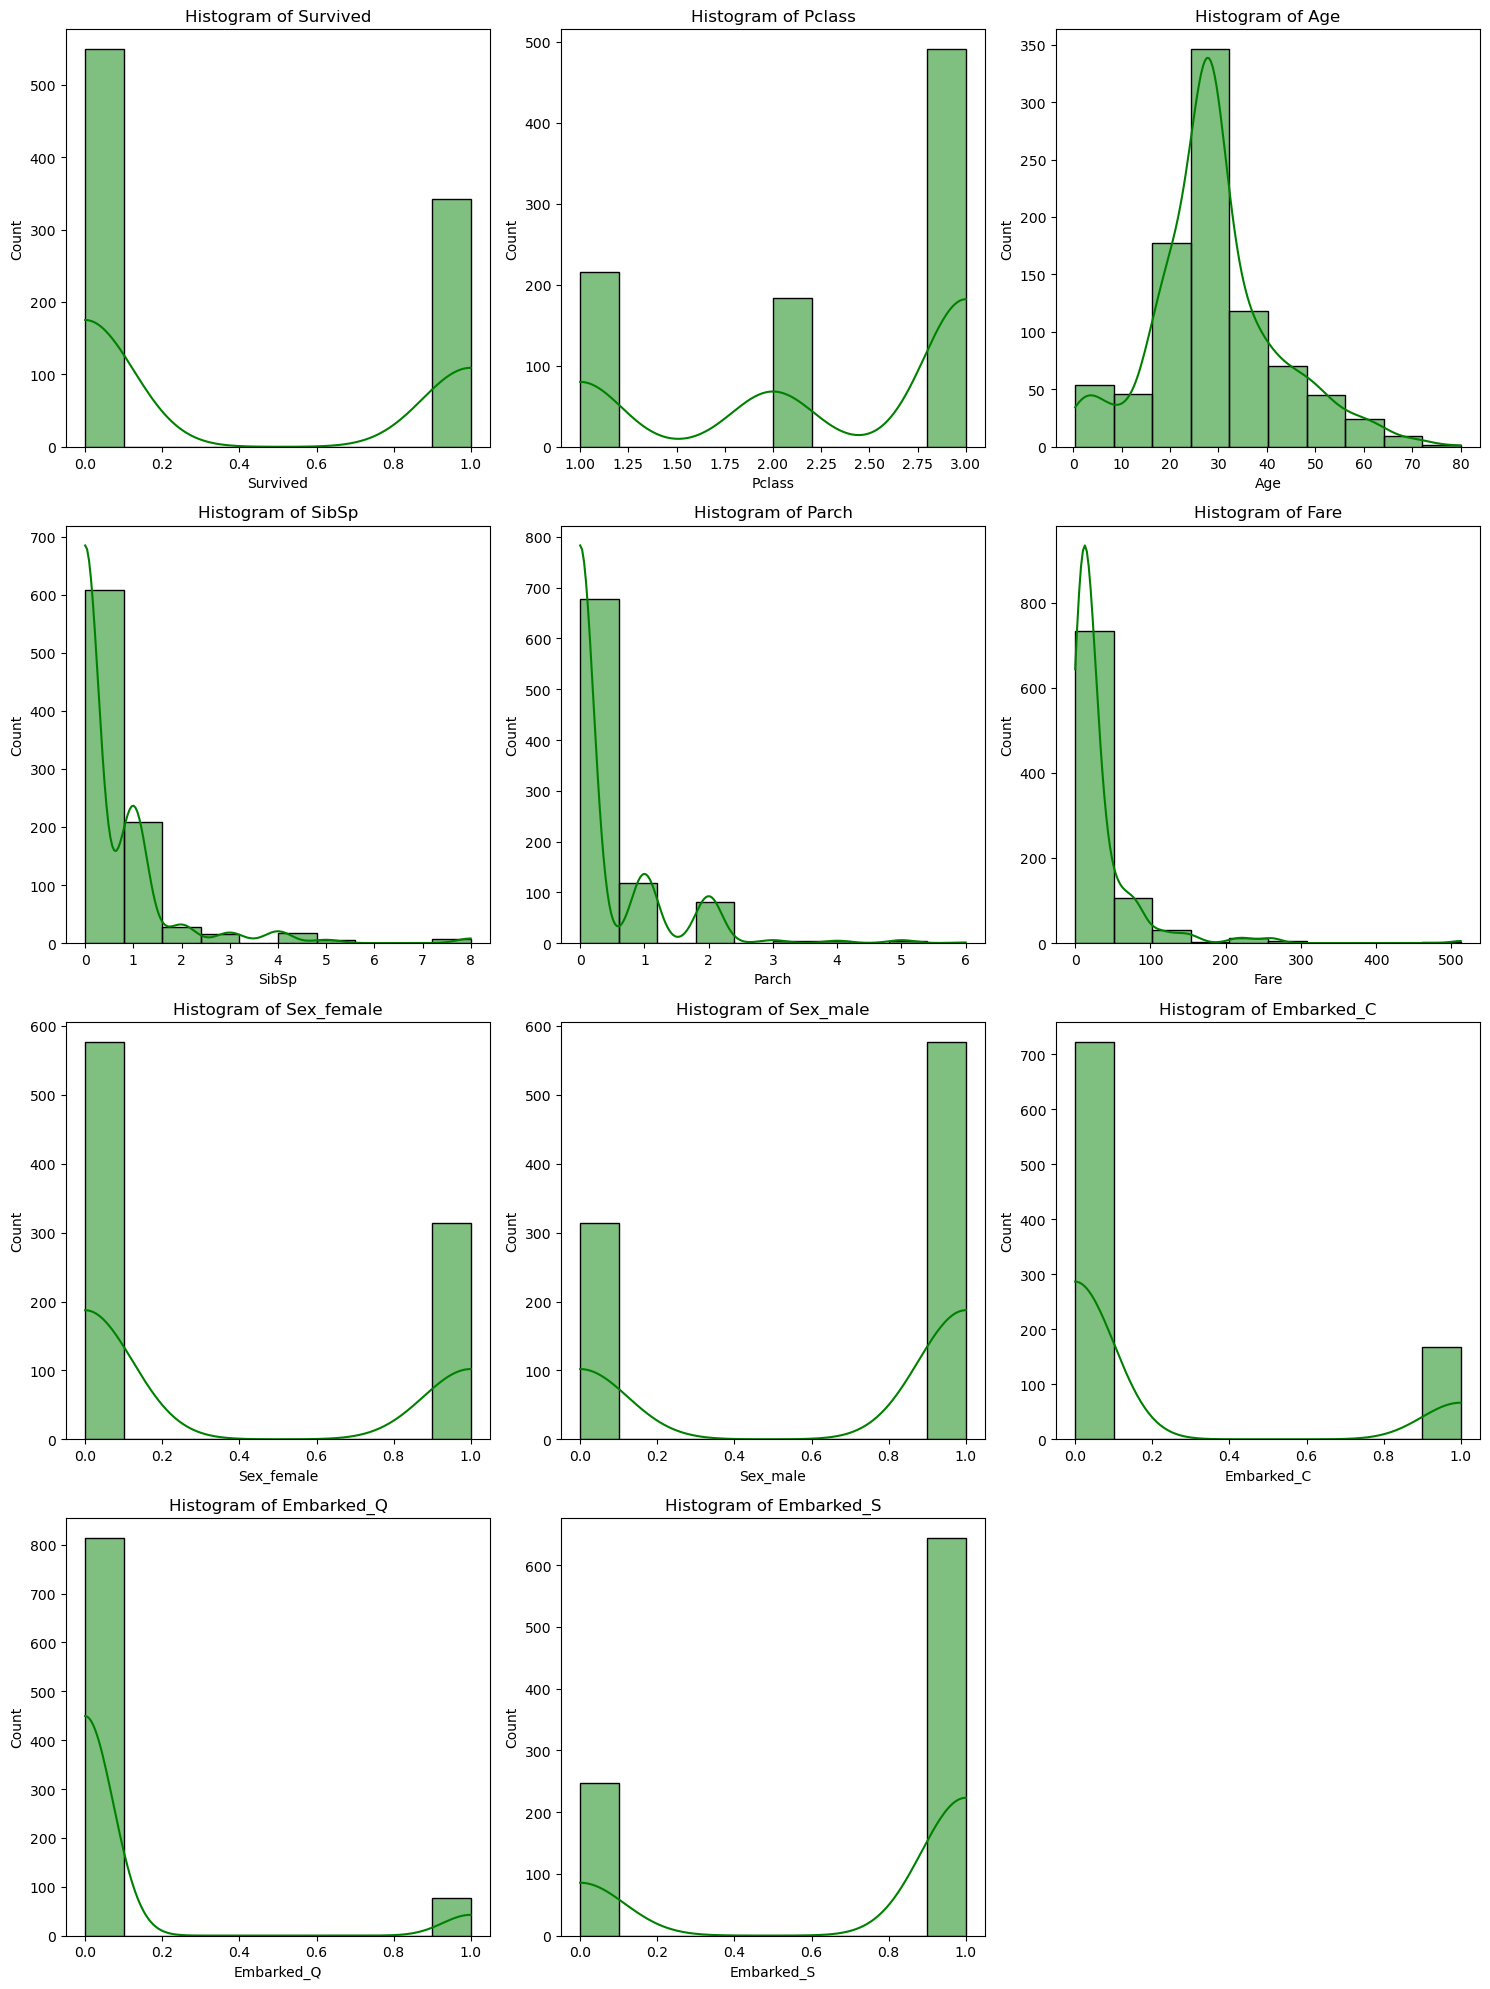

In [250]:
# Histogram after data cleaning

num_cols=len(titanic_df_n.columns)
rows=math.ceil(num_cols/3)

plt.figure(figsize=(15,rows*5))
for i,col in enumerate(titanic_df_n.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(titanic_df_n[col], kde=True, bins=10, color='green')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [252]:
titanic_df_n

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,22.0,1,0,7.2500,0,1,0,0,1
2,1,1,38.0,1,0,71.2833,1,0,1,0,0
3,1,3,26.0,0,0,7.9250,1,0,0,0,1
4,1,1,35.0,1,0,53.1000,1,0,0,0,1
5,0,3,35.0,0,0,8.0500,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,27.0,0,0,13.0000,0,1,0,0,1
888,1,1,19.0,0,0,30.0000,1,0,0,0,1
889,0,3,28.0,1,2,23.4500,1,0,0,0,1


In [269]:
# Calculate IQR of column 'Age'
Q1 = titanic_df_n['Age'].quantile(0.25)
Q3 = titanic_df_n['Age'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = titanic_df_n[(titanic_df_n['Age'] < (Q1 - 1.5 * IQR)) | (titanic_df_n['Age'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print (len(outliers))
print (Q1 - 1.5 * IQR)
print (Q3 + 1.5 * IQR)

Outliers based on IQR:
              Survived  Pclass    Age  SibSp  Parch     Fare  Sex_female  \
PassengerId                                                               
8                   0       3   2.00      3      1  21.0750           0   
12                  1       1  58.00      0      0  26.5500           1   
16                  1       2  55.00      0      0  16.0000           1   
17                  0       3   2.00      4      1  29.1250           0   
34                  0       2  66.00      0      0  10.5000           0   
...               ...     ...    ...    ...    ...      ...         ...   
828                 1       2   1.00      0      2  37.0042           0   
830                 1       1  62.00      0      0  80.0000           1   
832                 1       2   0.83      1      1  18.7500           0   
852                 0       3  74.00      0      0   7.7750           0   
880                 1       1  56.00      0      1  83.1583           1   



In [271]:
# Calculate IQR of column 'Parch'
Q1 = titanic_df_n['SibSp'].quantile(0.25)
Q3 = titanic_df_n['SibSp'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = titanic_df_n[(titanic_df_n['SibSp'] < (Q1 - 1.5 * IQR)) | (titanic_df_n['SibSp'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print (len(outliers))
print (Q1 - 1.5 * IQR)
print (Q3 + 1.5 * IQR)

Outliers based on IQR:
              Survived  Pclass   Age  SibSp  Parch      Fare  Sex_female  \
PassengerId                                                               
8                   0       3   2.0      3      1   21.0750           0   
17                  0       3   2.0      4      1   29.1250           0   
25                  0       3   8.0      3      1   21.0750           1   
28                  0       1  19.0      3      2  263.0000           0   
51                  0       3   7.0      4      1   39.6875           0   
60                  0       3  11.0      5      2   46.9000           0   
64                  0       3   4.0      3      2   27.9000           0   
69                  1       3  17.0      4      2    7.9250           1   
72                  0       3  16.0      5      2   46.9000           1   
86                  1       3  33.0      3      0   15.8500           1   
89                  1       1  23.0      3      2  263.0000           1   
1

In [279]:
# Calculate IQR
Q1 = titanic_df_n['Parch'].quantile(0.25)
Q3 = titanic_df_n['Parch'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = titanic_df_n[(titanic_df_n['Parch'] < (Q1 - 1.5 * IQR)) | (titanic_df_n['Parch'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print (len(outliers))
print (Q1)
print (Q3)
print (Q1 - 1.5 * IQR)
print (Q3 + 1.5 * IQR)

Outliers based on IQR:
              Survived  Pclass   Age  SibSp  Parch     Fare  Sex_female  \
PassengerId                                                              
8                   0       3   2.0      3      1  21.0750           0   
9                   1       3  27.0      0      2  11.1333           1   
11                  1       3   4.0      1      1  16.7000           1   
14                  0       3  39.0      1      5  31.2750           0   
17                  0       3   2.0      4      1  29.1250           0   
...               ...     ...   ...    ...    ...      ...         ...   
872                 1       1  47.0      1      1  52.5542           1   
880                 1       1  56.0      0      1  83.1583           1   
881                 1       2  25.0      0      1  26.0000           1   
886                 0       3  39.0      0      5  29.1250           1   
889                 0       3  28.0      1      2  23.4500           1   

             

In [275]:
titanic_df_n['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

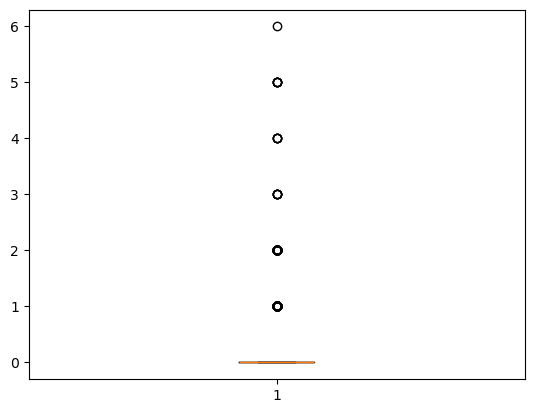

In [283]:
titanic_df_n1=titanic_df_n.Parch
# Rechecking outlier removal of column 'Parch' in the new dataframe.
b=plt.boxplot(titanic_df_n1)
plt.show()

In [285]:
# Calculate IQR of column 'Age'
Q1 = titanic_df_n['Fare'].quantile(0.25)
Q3 = titanic_df_n['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = titanic_df_n[(titanic_df_n['Fare'] < (Q1 - 1.5 * IQR)) | (titanic_df_n['Fare'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print (len(outliers))
print (Q1 - 1.5 * IQR)
print (Q3 + 1.5 * IQR)

Outliers based on IQR:
              Survived  Pclass   Age  SibSp  Parch      Fare  Sex_female  \
PassengerId                                                               
2                   1       1  38.0      1      0   71.2833           1   
28                  0       1  19.0      3      2  263.0000           0   
32                  1       1  28.0      1      0  146.5208           1   
35                  0       1  28.0      1      0   82.1708           0   
53                  1       1  49.0      1      0   76.7292           1   
...               ...     ...   ...    ...    ...       ...         ...   
847                 0       3  28.0      8      2   69.5500           0   
850                 1       1  28.0      1      0   89.1042           1   
857                 1       1  45.0      1      1  164.8667           1   
864                 0       3  28.0      8      2   69.5500           1   
880                 1       1  56.0      0      1   83.1583           1   



In [ ]:
# Outlier treatment should be done for the columns 'Age', 'Parch', 'SibSp' and 'Fare'. Outlier treatment is required to avoid data loss. 
# Capping technique is used. Replacing extreme values with the upper or lower bound.

In [287]:
# Capping of outliers

# List of columns to apply the bounds
columns = ['Age', 'Parch', 'SibSp', 'Fare']
import numpy as np
# Apply the bounds to each column
for col in columns:
    upper_bound = titanic_df_n[columns].quantile(0.25)
    lower_bound = titanic_df_n[columns].quantile(0.75)
    titanic_df_n[columns] = np.where(titanic_df_n[columns] > upper_bound, upper_bound, titanic_df_n[columns])
    titanic_df_n[columns] = np.where(titanic_df_n[columns] < lower_bound, lower_bound, titanic_df_n[columns])

# Print the updated DataFrame
print(titanic_df_n)


             Survived  Pclass   Age  SibSp  Parch  Fare  Sex_female  Sex_male  \
PassengerId                                                                     
1                   0       3  35.0    1.0    0.0  31.0           0         1   
2                   1       1  35.0    1.0    0.0  31.0           1         0   
3                   1       3  35.0    1.0    0.0  31.0           1         0   
4                   1       1  35.0    1.0    0.0  31.0           1         0   
5                   0       3  35.0    1.0    0.0  31.0           0         1   
...               ...     ...   ...    ...    ...   ...         ...       ...   
887                 0       2  35.0    1.0    0.0  31.0           0         1   
888                 1       1  35.0    1.0    0.0  31.0           1         0   
889                 0       3  35.0    1.0    0.0  31.0           1         0   
890                 1       1  35.0    1.0    0.0  31.0           0         1   
891                 0       

In [291]:
titanic_df_n.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_female    0
Sex_male      0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [293]:
titanic_df_n.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.0,891.0,891.0,891.0,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,35.0,1.0,0.0,31.0,0.352413,0.647587,0.188552,0.086420,0.722783
std,0.486592,0.836071,0.0,0.0,0.0,0.0,0.477990,0.477990,0.391372,0.281141,0.447876
min,0.000000,1.000000,35.0,1.0,0.0,31.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,35.0,1.0,0.0,31.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,35.0,1.0,0.0,31.0,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,3.000000,35.0,1.0,0.0,31.0,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,3.000000,35.0,1.0,0.0,31.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [295]:
# Splitting into train and test data

In [297]:
from sklearn.model_selection import train_test_split

In [302]:
# Splitting data into X and Y

In [304]:
titanic_df_n.shape

(891, 11)

In [308]:
array= titanic_df_n.values

In [314]:
X=array[:,1:11]

In [316]:
X

array([[ 3., 35.,  1., ...,  0.,  0.,  1.],
       [ 1., 35.,  1., ...,  1.,  0.,  0.],
       [ 3., 35.,  1., ...,  0.,  0.,  1.],
       ...,
       [ 3., 35.,  1., ...,  0.,  0.,  1.],
       [ 1., 35.,  1., ...,  1.,  0.,  0.],
       [ 3., 35.,  1., ...,  0.,  1.,  0.]])

In [328]:
Y=array[:,0]

In [330]:
Y

array([0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1.,
       0., 0., 0., 1., 0.

In [332]:
# titanic_df_n

In [334]:
# Splitting into train and test splits

In [367]:
x_train, x_test, y_train, y_test = train_test_split(X, Y , test_size=0.2, random_state =40)

# test_size=0.2 mean 80 by 20 split where 20% of data will be considered as test and remaining as training data.

In [372]:
x_train.shape

(712, 10)

In [374]:
y_train.shape

(712,)

In [376]:
x_test.shape

(179, 10)

In [378]:
y_test.shape

(179,)

# Building LGBM model

In [386]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 1: Define the parameter grid for tuning


param_dist= {
    'num_leaves':[31,50,70, 86, 100, 120],
    'max_depth':[3, 4, 5, 8, 10, 12, 15],
    'learning_rate':[0.01, 0.05, 0.1, 0.2],
    'n_estimators':[50,100,150,200],
    'min_child_samples':[20, 50, 100]
}

# Step 2: Create the LightGBM model

lgbm_model = LGBMClassifier(random_state=42)


# Step 3: Perform RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist,
    n_iter=20,  # Number of random combinations to try
    scoring='accuracy',  # Metric to optimize
    cv=5,  # Cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1
)


# Step 4: Fit the model on the training data
random_search.fit(x_train, y_train)


# Step 5: Print the best hyperparameters
print("Best Hyperparameters for LightGBM:", random_search.best_params_)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 266, number of negative: 446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373596 -> initscore=-0.516823
[LightGBM] [Info] Start training from score -0.516823
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

In [388]:
# Make predictions on the test set
y_pred = random_search.predict(x_test)

In [390]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'binary' for binary classification
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')



# Print the evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.82
Precision: 0.84
Recall: 0.82
F1-score: 0.81

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.96      0.86       103
         1.0       0.92      0.63      0.75        76

    accuracy                           0.82       179
   macro avg       0.85      0.80      0.81       179
weighted avg       0.84      0.82      0.81       179



In [ ]:
# Perform 5 fold cross validation

In [399]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lgbm_model, X, Y, cv=5, scoring='accuracy', n_jobs=-1)

# Print individual fold scores
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: Accuracy = {score:.2f}")

# Print the mean and standard deviation of cross-validation scores
print(f"Cross-validation Accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

C:\Users\Smrithi\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fold 1: Accuracy = 0.80
Fold 2: Accuracy = 0.82
Fold 3: Accuracy = 0.83
Fold 4: Accuracy = 0.79
Fold 5: Accuracy = 0.81
Cross-validation Accuracy: 0.81 ± 0.02


# Model building using XGBoost

In [407]:
pip install xgboost

In [409]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score

In [411]:
X.shape

(891, 10)

In [413]:
Y.shape

(891,)

In [415]:
x_train.shape

(712, 10)

In [417]:

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

In [421]:
# Split the data into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [423]:
xgb_model = XGBClassifier(random_state=42)

In [ ]:
# We will perform random search over a predefined grid of hyperparameters and use 10-fold cross-validation to find the best combination.

In [427]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Randomized search with 10-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model to the training data
random_search.fit(x_train, y_train)

# Print the best parameters
print("Best Hyperparameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'subsample': 0.6, 'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
# subsample:
# Description: This parameter specifies the fraction of the training data that is used to train each tree. It randomly samples the data before fitting a tree.
# Values: A value of 1.0 means using all the training data for every tree, while values less than 1.0 means using a portion of the data.
# Effect: Using a value less than 1.0 can introduce randomness into the model, which helps to reduce overfitting. However, setting it too low might lead to underfitting.

# colsample_bytree:
# Description: This parameter specifies the fraction of features (columns) to be randomly sampled for each tree.
# Values: A value of 1.0 means using all the features for every tree, while values less than 1.0 means using a portion of the features.
# Effect: Using a value less than 1.0 can help prevent overfitting by introducing randomness in the feature selection process for each tree. It can also 
# reduce computational cost when working with a large number of features.

In [429]:
print("Best estimators:", random_search.best_estimator_)

Best estimators: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)


In [431]:
# Get the best model from RandomizedSearchCV
best_xgb_model = random_search.best_estimator_

# Train the model on the training set
best_xgb_model.fit(x_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
# We will evaluate the model using accuracy, precision, recall, and F1-score.

In [526]:
# Predict on the test set
y_pred_1 = best_xgb_model.predict(x_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_1)
precision = precision_score(y_test, y_pred_1, average='weighted')  # Use 'weighted' for multiclass classification
recall = recall_score(y_test, y_pred_1, average='weighted')
f1 = f1_score(y_test, y_pred_1, average='weighted')


# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")


# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_1))

Accuracy: 0.79
Precision: 0.80
Recall: 0.79
F1-score: 0.79

Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.90      0.84       105
         1.0       0.82      0.64      0.72        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179



In [528]:
y_pred_1

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0])

In [ ]:
# To further confirm the model's stability, perform 5-fold cross-validation on the training set using the best model.

In [437]:
cv_scores = cross_val_score(best_xgb_model, X, Y, cv=5, scoring='accuracy')


# Print individual fold scores
for i, score in enumerate(cv_scores):
    print (f"Fold {i+1}: Accuracy={score:.2f}")
    

# Print the mean and standard deviation of cross-validation accuracy scores
print(f"Cross-validation Accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")


Fold 1: Accuracy=0.80
Fold 2: Accuracy=0.82
Fold 3: Accuracy=0.83
Fold 4: Accuracy=0.79
Fold 5: Accuracy=0.81
Cross-validation Accuracy: 0.81 ± 0.02


# Comparative Analysis:

In [440]:
# Code to compare performance metrics

In [466]:



# Performance metrics for LightGBM and XGBoost

metrics = {"Model":['LGBM','XGBM'],
          "Accuracy":[0.82,0.79],
          "Precision": [0.84, 0.80],
          "Recall":[0.82, 0.79],
          "F1-score":[0.81, 0.79]}

# Convert the metircs dictionary into dataframe

metrics_df = pd.DataFrame(metrics)

In [468]:
metrics_df

,Model,Accuracy,Precision,Recall,F1-score
0,LGBM,0.82,0.84,0.82,0.81
1,XGBM,0.79,0.80,0.79,0.79


In [450]:
# Visualize the performance metrics

In [452]:
# Plot a bar chart for comparison

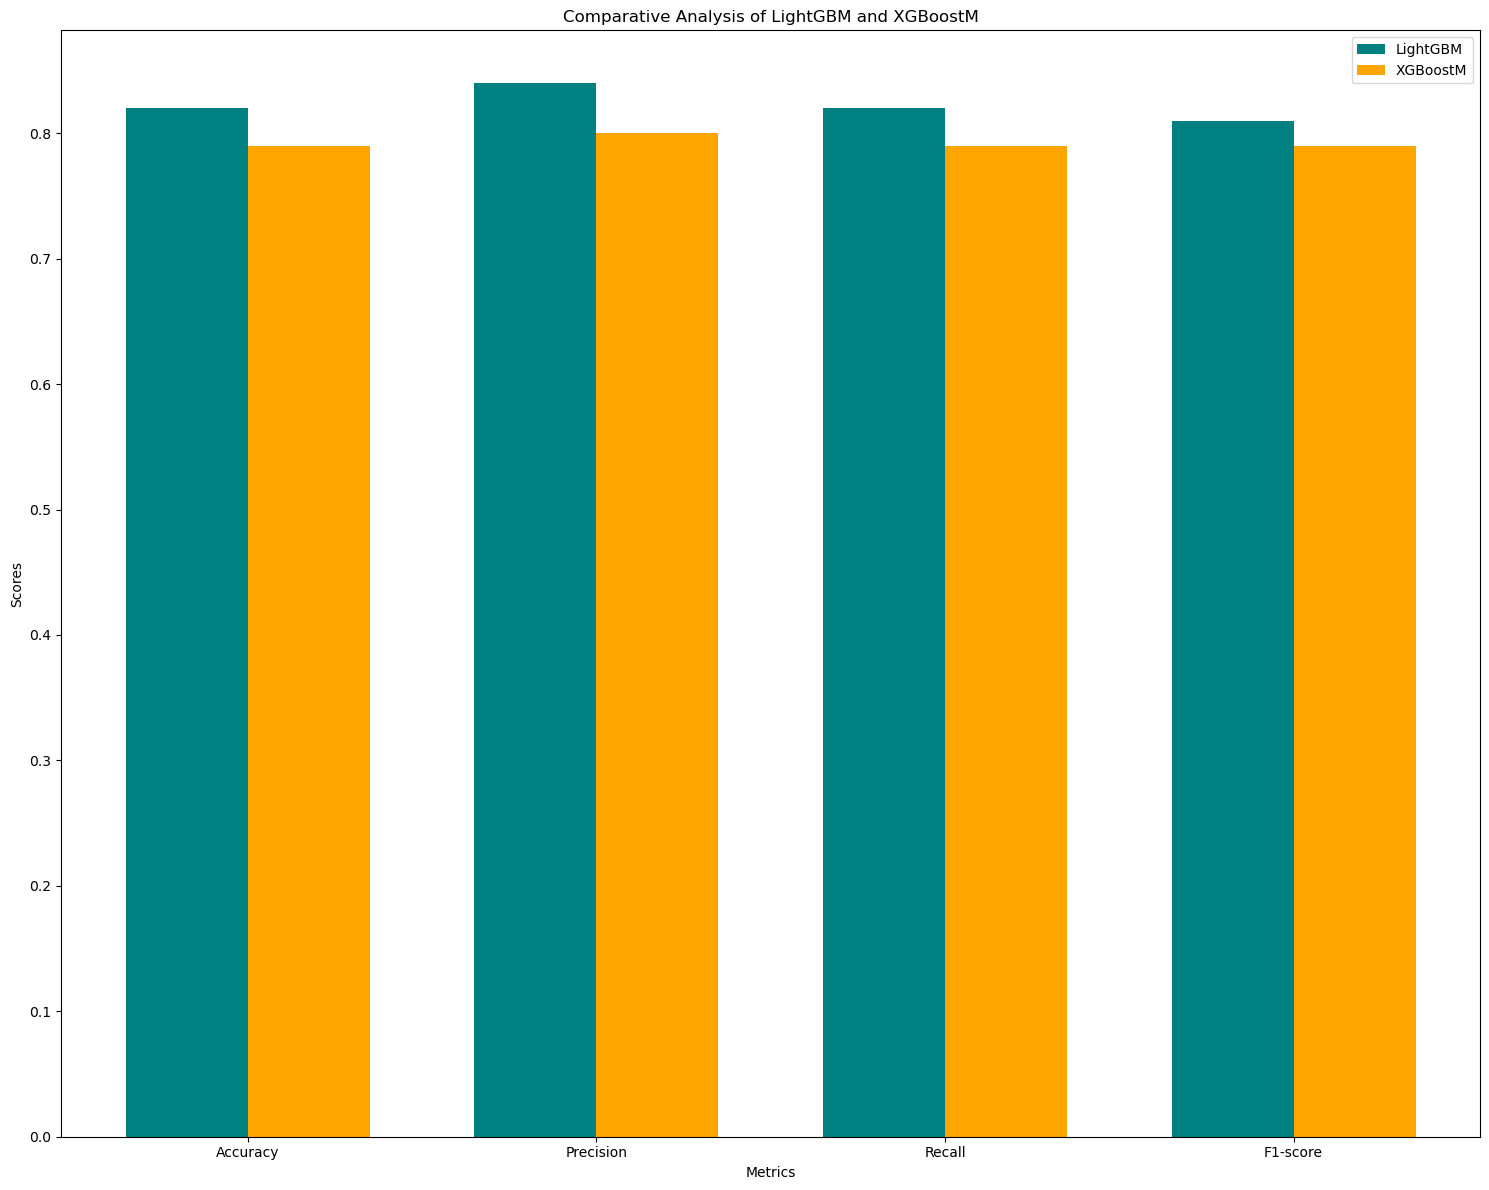

In [474]:
fig, ax = plt.subplots(figsize=(15,12))

# Plot bars for each metric
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics_to_plot))

# print (x)
bar_width = 0.35
ax.bar(x - bar_width/2, metrics_df.loc[0, metrics_to_plot], width=bar_width, label='LightGBM', color='teal')
ax.bar(x + bar_width/2, metrics_df.loc[1, metrics_to_plot], width=bar_width, label='XGBoostM', color='orange')

# Customize the plot
ax.set_xlabel("Metrics")
ax.set_ylabel("Scores")
ax.set_title("Comparative Analysis of LightGBM and XGBoostM")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()

In [476]:
# Analyze and Interpret the Results
# Here’s a sample summary report based on the provided metrics.

# Enhancing the analysis by adding ROC curves and confusion matrices for both LGBM and XGBM for indepth analysis.

In [480]:
# Import required libraries

In [482]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

In [484]:
# Plot ROC curves for both the models

In [486]:
# Predicted probabilities from both models

In [488]:
lgbm_probs = random_search.predict_proba(x_test)[:,1]  
# Probabilities for the class 1

xgb_probs = best_xgb_model.predict_proba(x_test)[:,1]

In [ ]:
# Generate ROC curves and compute AUC scores

In [493]:
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

lgbm_auc = roc_auc_score(y_test, lgbm_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

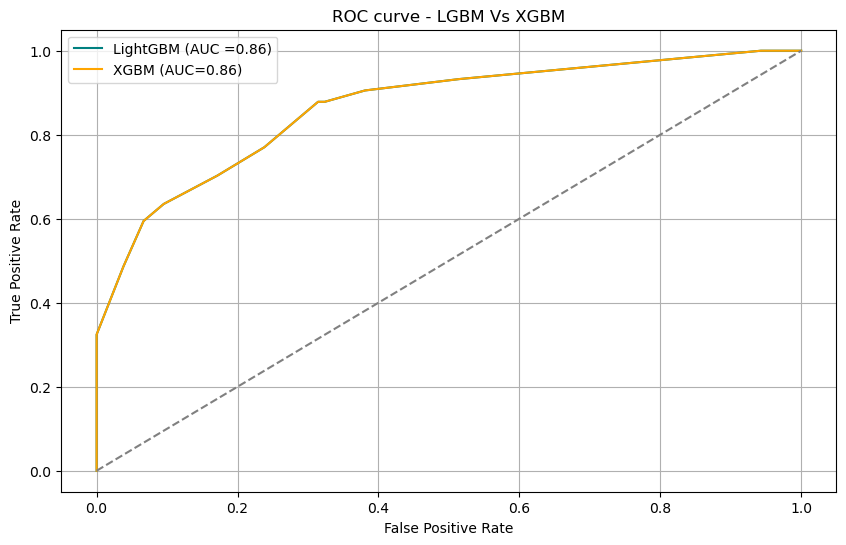

In [505]:
# Plot the ROC curves


plt.figure(figsize=(10,6))
plt.plot(lgbm_fpr, lgbm_tpr, label=f'LightGBM (AUC ={lgbm_auc:.2f})', color='teal')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBM (AUC={xgb_auc:.2f})',color='orange')
plt.plot([0,1],[0,1], linestyle='--', color = 'gray')     #Diagonal line for random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve - LGBM Vs XGBM')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# ROC Curve:
# This plot helps you visualize how well each model separates the two classes. 
# The higher the AUC (area under the curve), the better the model’s performance.

# Since both the models have AUC= 0.86, this implies there is no significant difference between the two models.

In [ ]:
# Plotting confusion metrics

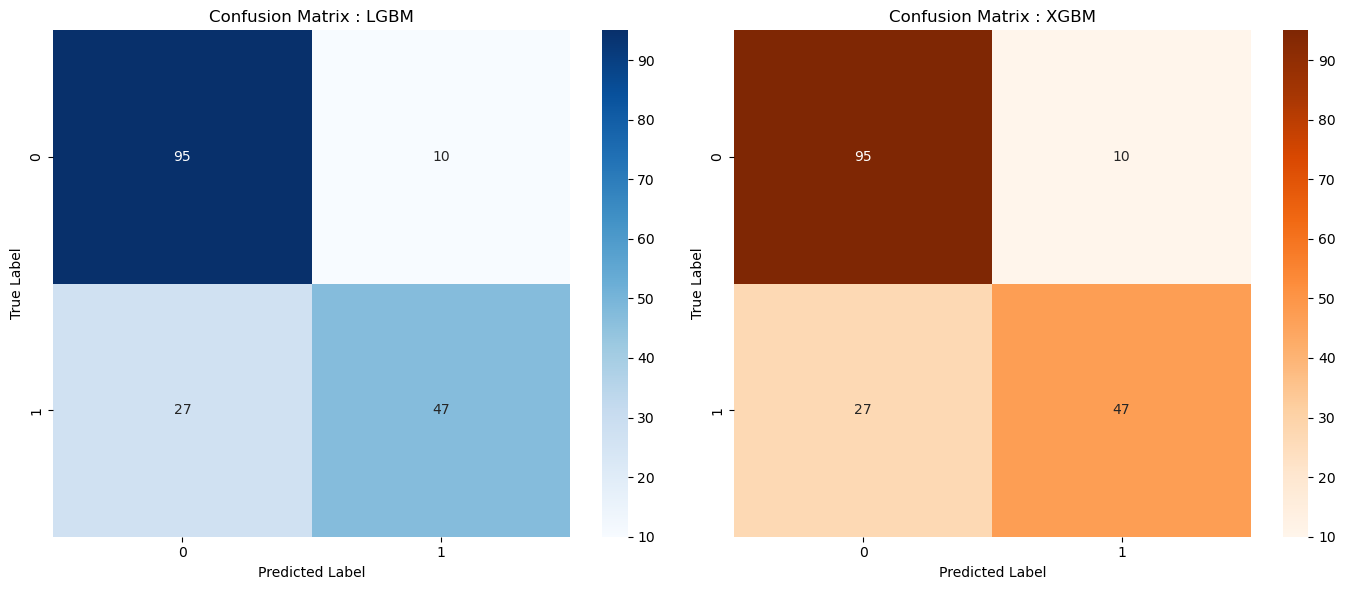

In [518]:
# Generate confusion metrices

lgbm_cm=confusion_matrix(y_test, y_pred)
xgb_cm=confusion_matrix(y_test, y_pred_1)

# Plot confusion matrix for LGBM

fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.heatmap(lgbm_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0] )
ax[0].set_title('Confusion Matrix : LGBM')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# Plot confusion matrix for XGBoost

sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('Confusion Matrix : XGBM')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')


plt.tight_layout()
plt.show()